In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

# project root 등록
PROJECT_ROOT = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07"
sys.path.append(PROJECT_ROOT)

from src.data.train_data import XRayDataset
from src.metrics.dice import dice_coef
from src.configs.defaults import CLASSES, IND2CLASS

In [2]:
CKPT_PATH = (
    "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/outputs/checkpoints/final_baseline_unetpp_resnext50_32x4d_basnet_ref_bce_dice_img2048_fold0/unetpp_resnext50_32x4d_basnet_ref_bce_dice_imagenet_fold0_e60_best.pt"
)

model = torch.load(CKPT_PATH, weights_only=False)
model = model.cuda()
model.eval()

print("✅ Model loaded")

✅ Model loaded


In [3]:
FOLD = 0

valid_dataset = XRayDataset(
    fold=FOLD,
    is_train=False
)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=1,        # threshold 튜닝은 반드시 1
    shuffle=False,
    num_workers=0,
    drop_last=False
)

print(f"✅ Validation samples: {len(valid_dataset)}")

✅ Validation samples: 160


In [4]:
def validation_dice_per_class(model, data_loader, thresholds):
    model.eval()

    dice_per_thr = {thr: [] for thr in thresholds}

    with torch.no_grad():
        for images, masks in tqdm(data_loader):
            images = images.cuda()
            masks = masks.cuda()

            outputs = model(images)
            if isinstance(outputs, dict):
                outputs = outputs["seg"]

            probs = torch.sigmoid(outputs)

            for thr in thresholds:
                preds = (probs > thr).float()
                dice = dice_coef(masks, preds)   # (B, C)
                dice_per_thr[thr].append(dice)

    dice_mean = {}
    dice_classwise = {}

    for thr in thresholds:
        all_dice = torch.cat(dice_per_thr[thr], dim=0)  # (N, C)
        dice_classwise[thr] = all_dice.mean(dim=0)      # (C,)
        dice_mean[thr] = all_dice.mean().item()

    return dice_mean, dice_classwise

In [5]:
thresholds = torch.linspace(0.1, 0.9, 17).tolist()

dice_mean_results, dice_per_class_results = validation_dice_per_class(
    model,
    valid_loader,
    thresholds
)

  0%|          | 0/160 [00:00<?, ?it/s]

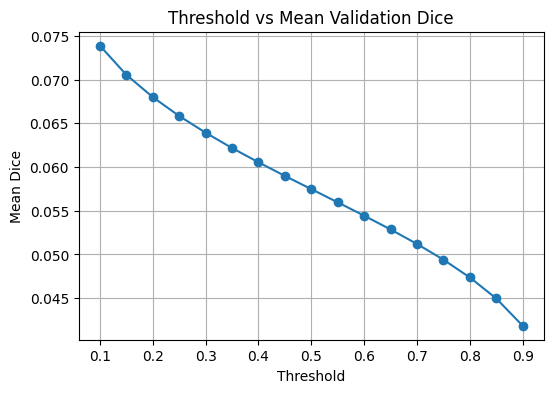

In [6]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, [dice_mean_results[t] for t in thresholds], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Mean Dice")
plt.title("Threshold vs Mean Validation Dice")
plt.grid(True)
plt.show()


In [7]:
best_thr_per_class = {}

dice_stack = torch.stack(
    [dice_per_class_results[t] for t in thresholds], dim=0
)  # (T, C)

for c in range(dice_stack.shape[1]):
    best_idx = torch.argmax(dice_stack[:, c])
    best_thr = thresholds[best_idx]
    best_dice = dice_stack[best_idx, c].item()

    best_thr_per_class[IND2CLASS[c]] = {
        "best_thr": best_thr,
        "best_dice": best_dice
    }

for cls, v in best_thr_per_class.items():
    print(f"{cls:<12} | thr={v['best_thr']:.2f} | dice={v['best_dice']:.4f}")

mean_dice = np.mean([v["best_dice"] for v in best_thr_per_class.values()])
print(f"\n📊 Mean Dice (class-wise threshold): {mean_dice:.4f}")

finger-1     | thr=0.10 | dice=0.0666
finger-2     | thr=0.10 | dice=0.0152
finger-3     | thr=0.10 | dice=0.0486
finger-4     | thr=0.10 | dice=0.1290
finger-5     | thr=0.10 | dice=0.0100
finger-6     | thr=0.10 | dice=0.0239
finger-7     | thr=0.10 | dice=0.0332
finger-8     | thr=0.10 | dice=0.1018
finger-9     | thr=0.10 | dice=0.0322
finger-10    | thr=0.10 | dice=0.0197
finger-11    | thr=0.10 | dice=0.0582
finger-12    | thr=0.10 | dice=0.1148
finger-13    | thr=0.10 | dice=0.0166
finger-14    | thr=0.10 | dice=0.0052
finger-15    | thr=0.10 | dice=0.0414
finger-16    | thr=0.10 | dice=0.0463
finger-17    | thr=0.10 | dice=0.1685
finger-18    | thr=0.10 | dice=0.0345
finger-19    | thr=0.10 | dice=0.0281
Trapezium    | thr=0.10 | dice=0.0387
Trapezoid    | thr=0.10 | dice=0.0258
Capitate     | thr=0.10 | dice=0.2878
Hamate       | thr=0.10 | dice=0.0349
Scaphoid     | thr=0.10 | dice=0.0807
Lunate       | thr=0.10 | dice=0.1069
Triquetrum   | thr=0.10 | dice=0.0061
Pisiform    